In [5]:
import pandas as pd
dataset = pd.read_csv('C:\\Users\\Enass Irfan\\Downloads\\AB_NYC_2019.csv')

dataset

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


#  Data Cleaning

In [10]:
#Remove unwanted columns
dataset.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [20]:
ds_new = dataset[['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews','calculated_host_listings_count',
       'availability_365']]
ds_new


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,Private room,149,1,9,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,Private room,150,3,0,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,Private room,70,2,0,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,Private room,40,4,0,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,Entire home/apt,115,10,0,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,Shared room,55,1,0,6,2


In [15]:
ds_new.isnull().sum()


id                                 0
name                              16
host_id                            0
host_name                         21
neighbourhood_group                0
neighbourhood                      0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

#  2.1 Handling missing values

In [ ]:
#Fill name and host_name missing values
ds_new['name'].fillna('No Name ', inplace = True)
ds_new['host_name'].fillna('Unknown Host', inplace = True)

#  2.2 Remove duplicates

In [21]:
#Check duplicate
duplicate_rows = ds_new.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

#Since there are no duplicate rows there is no need to remove it


Number of duplicate rows: 0


#  2.3 Identify and Manage Outliers

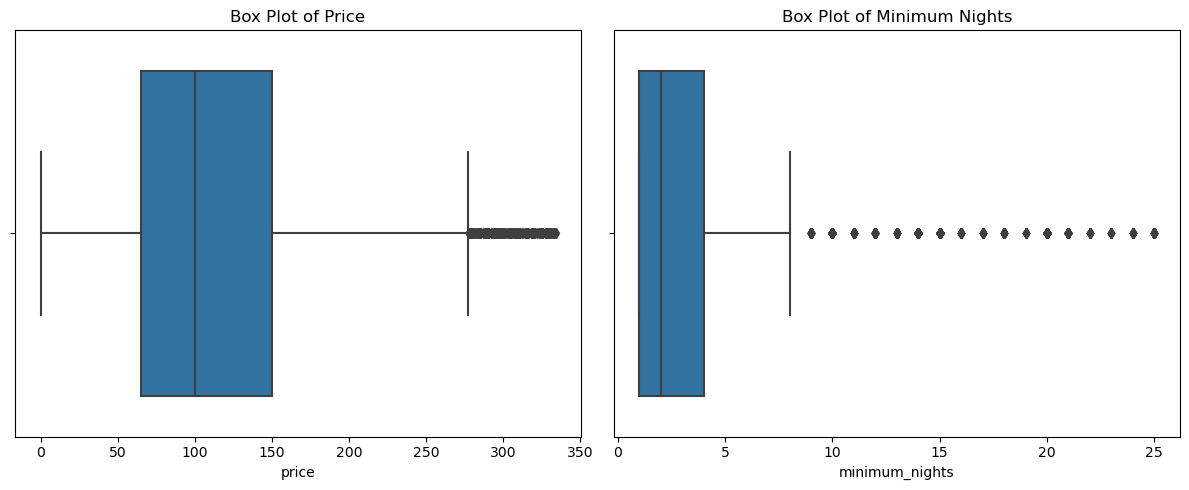

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=ds_new['price'])
plt.title('Box Plot of Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=ds_new['minimum_nights'])
plt.title('Box Plot of Minimum Nights')

plt.tight_layout()
plt.show()

In [45]:
#Price
Q1_price = ds_new['price'].quantile(0.25)
Q3_price = ds_new['price'].quantile(0.75)
IQR = Q3_price - Q1_price 
lbp = Q1_price - 1.5 * IQR
ubp = Q3_price +1.5 * IQR
ds_price_outliers = ds_new[(ds_new['price'] >= lbp) & (ds_new['price'] <= ubp)]
print(f"\nNumber of rows after removing price outliers (IQR): {len(ds_price_outliers)}")


#Minimum nights
ds_minNights_outliers = ds_price_outliers[ds_price_outliers['minimum_nights'] <= 30]
print(f"Number of rows after removing minimum_nights outliers (> 30 nights): {len(ds_minNights_outliers)}")
ds_cleaned = ds_minNights_outliers.copy()


Number of rows after removing price outliers (IQR): 39893
Number of rows after removing minimum_nights outliers (> 30 nights): 39893


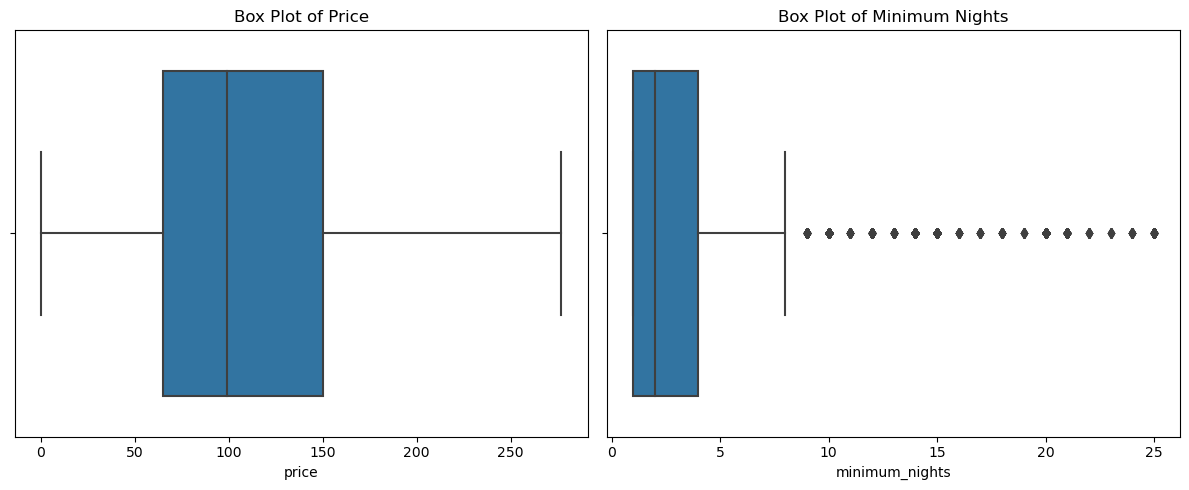

In [46]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=ds_cleaned['price'])
plt.title('Box Plot of Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=ds_cleaned['minimum_nights'])
plt.title('Box Plot of Minimum Nights')

plt.tight_layout()
plt.show()

#  Visualization

#  3.1 Bar charts

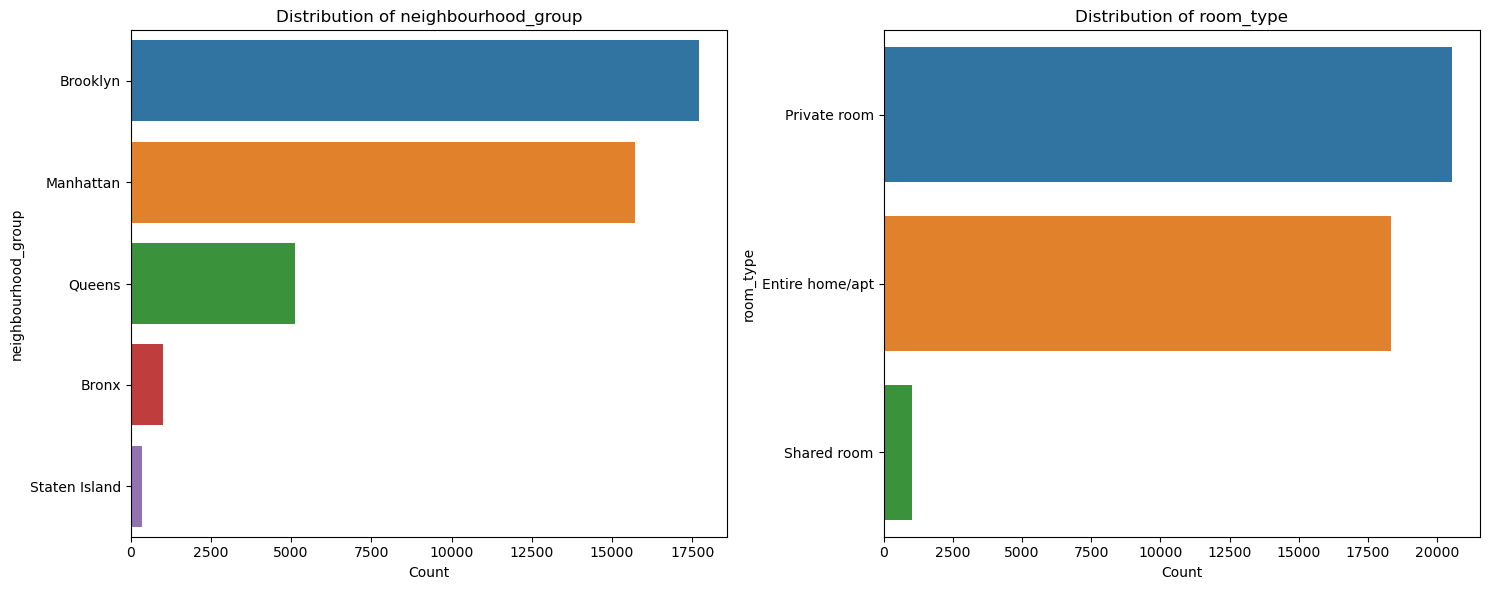

In [47]:
cols = ['neighbourhood_group','room_type']
plt.figure(figsize=(15,6))
for i , col in enumerate(cols):
    plt.subplot(1, len(cols), i+1)
    sns.countplot(data = ds_cleaned, y = col , order = ds_cleaned[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
plt.tight_layout()
plt.show()

# 3.2 Histogram

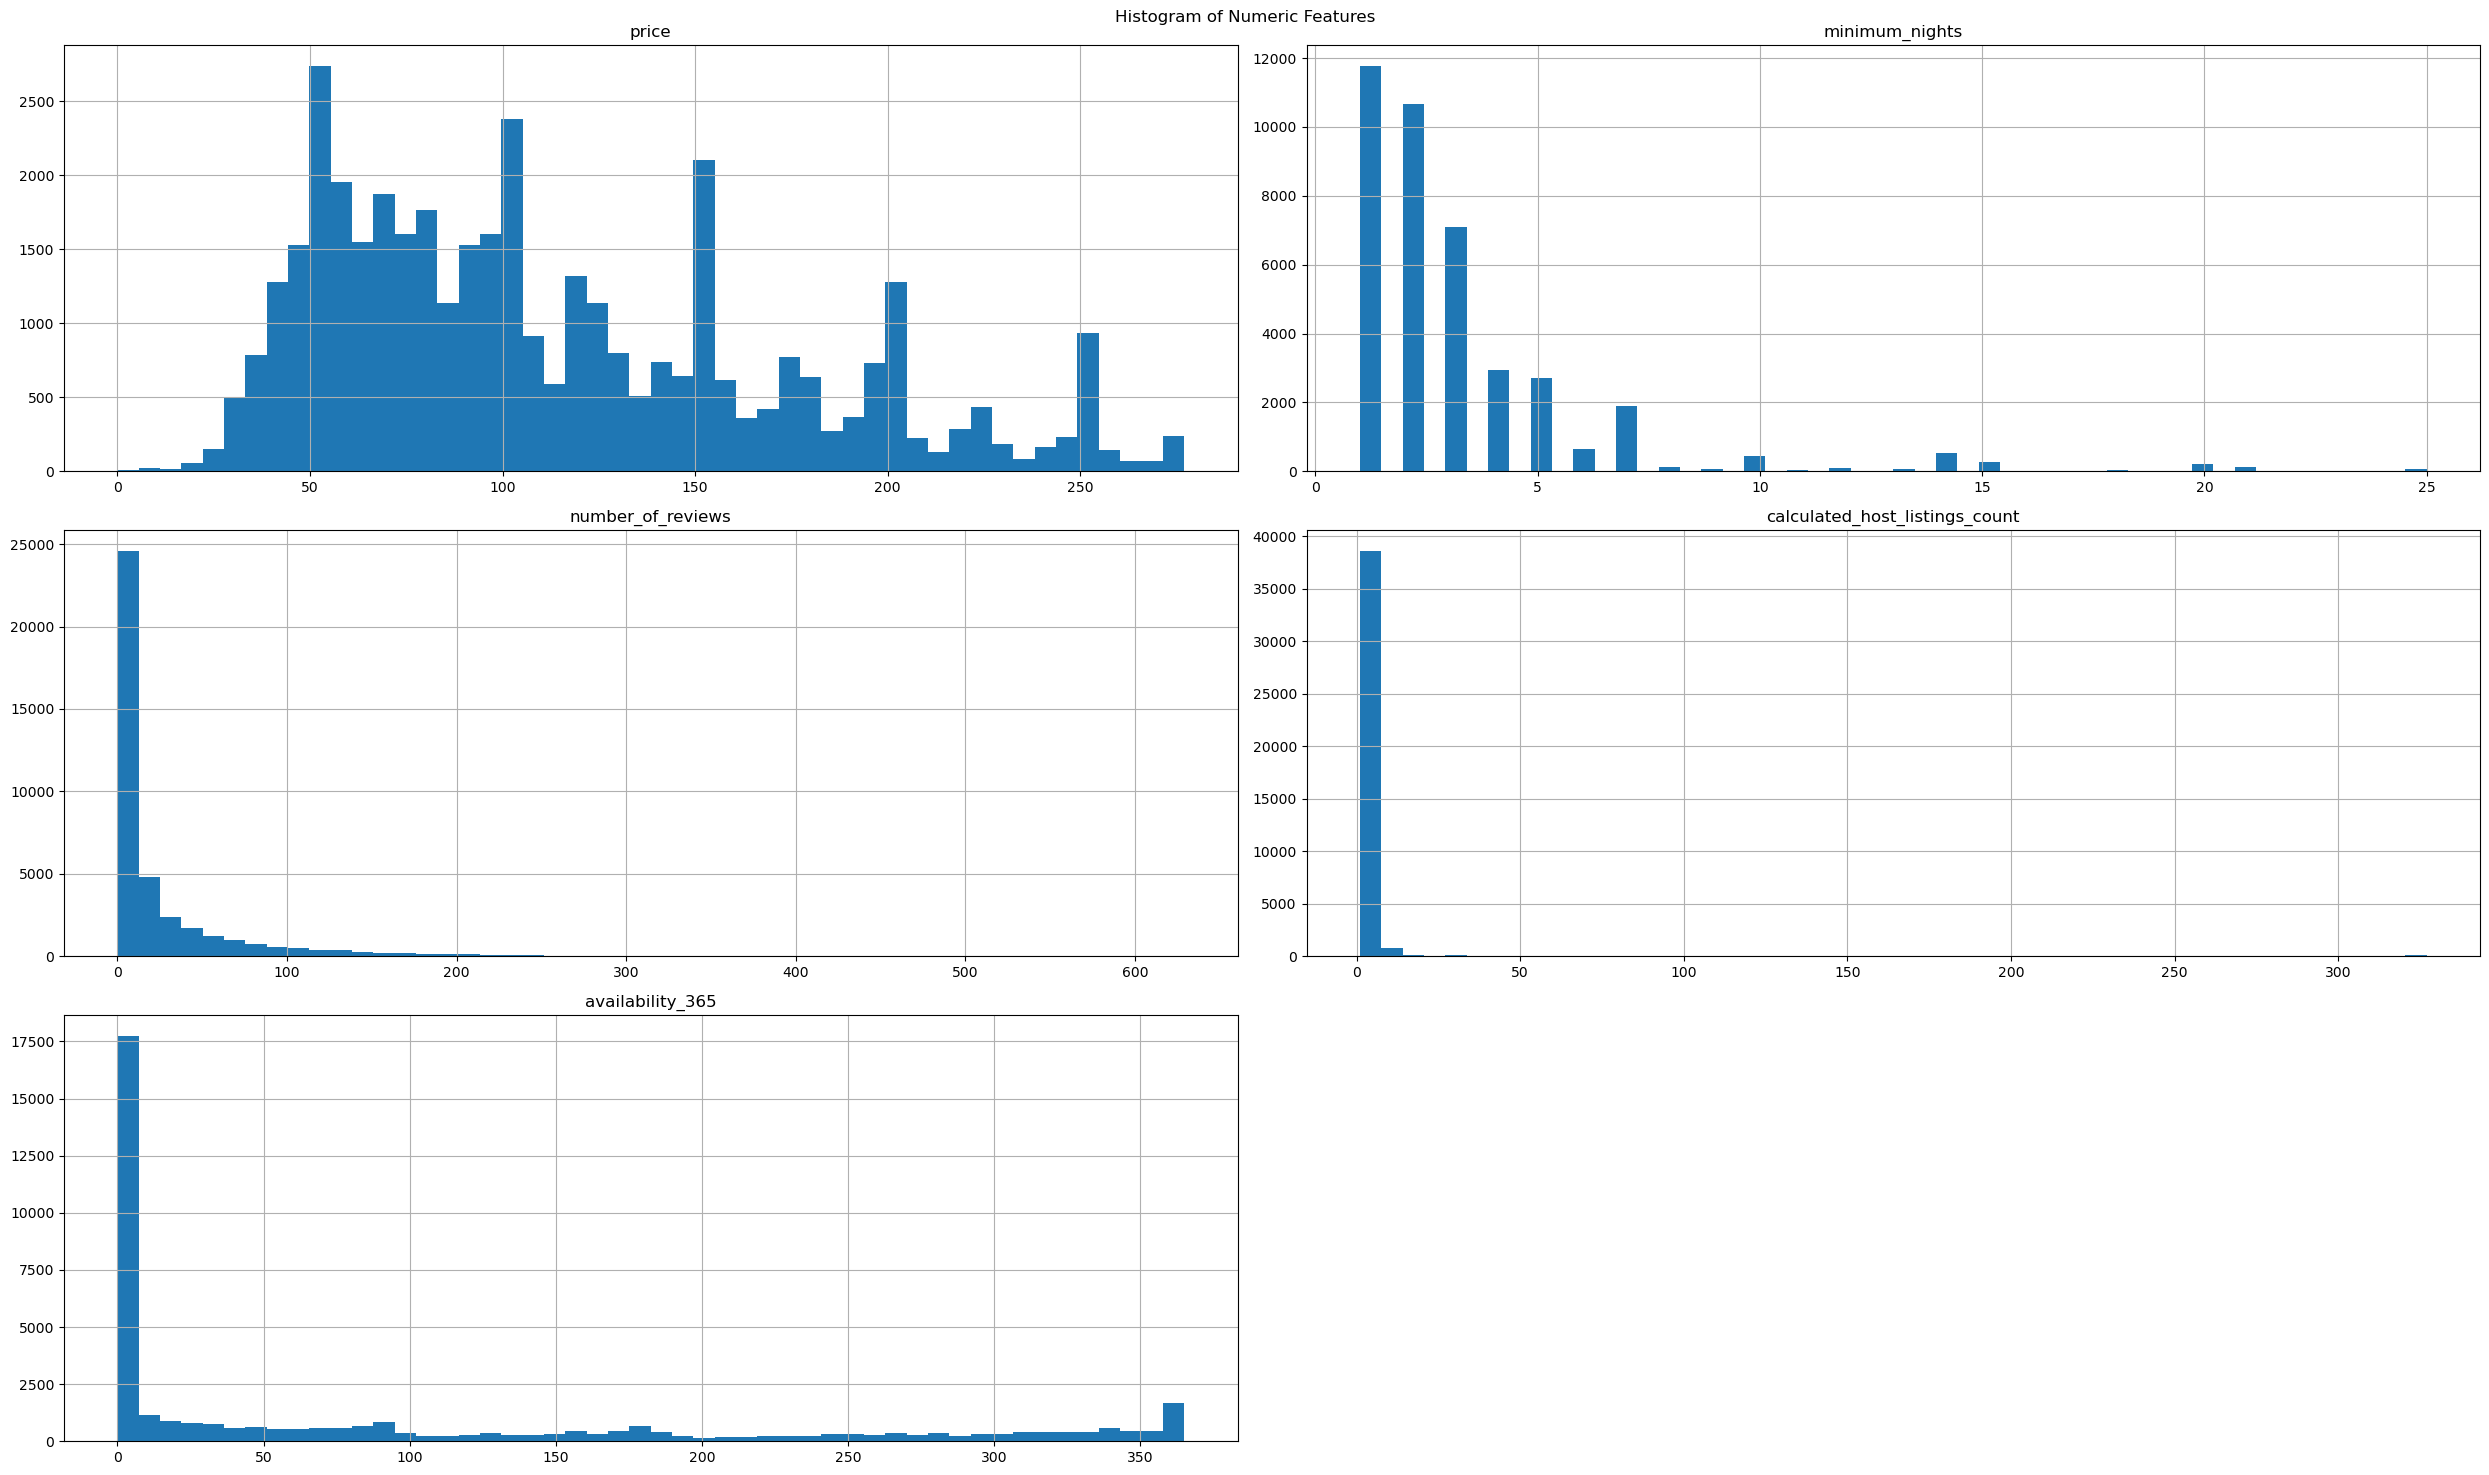

In [50]:
numeric_columns = ['price','minimum_nights','number_of_reviews', 'calculated_host_listings_count', 'availability_365']

ds_numeric = ds_cleaned[numeric_columns]
ds_numeric.hist(figsize=(25,15), bins = 50)
plt.suptitle('Histogram of Numeric Features')
plt.tight_layout()
plt.show()

#  3.3 Heatmap

In [ ]:
corr_matrix = ds_numeric.corr()
plt.figure(figsize=(15,6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Correlation Heatmap ')
plt.show()